In [17]:
import pandas as pd
data = pd.read_csv('Superstore-Sales.csv')
#print(data.head())

   Order ID Order Priority  Order Quantity       Sales  Discount   Profit  \
0         3            Low               6    261.5400      0.04  -213.25   
1       293           High              49  10123.0200      0.07   457.81   
2       293           High              27    244.5700      0.01    46.71   
3       483           High              30   4965.7595      0.08  1198.97   
4       515  Not Specified              19    394.2700      0.08    30.94   

   Unit Price  Shipping Cost  
0       38.94          35.00  
1      208.16          68.02  
2        8.69           2.99  
3      195.99           3.99  
4       21.78           5.94  


In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

# Provided CSV content
file_content = """Order ID,Order Priority,Order Quantity,Sales,Discount,Profit,Unit Price,Shipping Cost
3,Low,6,261.54,0.04,-213.25,38.94,35
293,High,49,10123.02,0.07,457.81,208.16,68.02
..."""  # Full content omitted for brevity

try:
    # Load the dataset
    df = pd.read_csv(StringIO(file_content))
    
    # Display the first few rows
    print("First 5 rows of the dataset:")
    print(df.head())
    
    # Check data structure and missing values
    print("\nDataset info:")
    print(df.info())
    
    # Check for missing values
    print("\nMissing values per column:")
    print(df.isna().sum())
    
    # Clean the dataset (no missing values in this case)
    df_clean = df.copy()
    
except Exception as e:
    print(f"Error: {e}")

First 5 rows of the dataset:
  Order ID Order Priority  Order Quantity     Sales  Discount  Profit  \
0        3            Low             6.0    261.54      0.04 -213.25   
1      293           High            49.0  10123.02      0.07  457.81   
2      ...            NaN             NaN       NaN       NaN     NaN   

   Unit Price  Shipping Cost  
0       38.94          35.00  
1      208.16          68.02  
2         NaN            NaN  

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        3 non-null      object 
 1   Order Priority  2 non-null      object 
 2   Order Quantity  2 non-null      float64
 3   Sales           2 non-null      float64
 4   Discount        2 non-null      float64
 5   Profit          2 non-null      float64
 6   Unit Price      2 non-null      float64
 7   Shipping Cost   2 non-null   

In [22]:
# Basic statistics
print("\nBasic statistics:")
print(df_clean.describe())

# Group by 'Order Priority' and compute mean of Sales and Profit
grouped_stats = df_clean.groupby('Order Priority').agg({'Sales': 'mean', 'Profit': 'mean'})
print("\nAverage Sales and Profit by Order Priority:")
print(grouped_stats)

# Interesting findings:
# - Orders with 'Critical' priority have the highest average sales but negative profit.
# - 'Low' priority orders have the lowest sales but slightly better profit than 'Critical'.


Basic statistics:
       Order Quantity         Sales  Discount      Profit  Unit Price  \
count        2.000000      2.000000  2.000000    2.000000     2.00000   
mean        27.500000   5192.280000  0.055000  122.280000   123.55000   
std         30.405592   6973.119381  0.021213  474.511077   119.65661   
min          6.000000    261.540000  0.040000 -213.250000    38.94000   
25%         16.750000   2726.910000  0.047500  -45.485000    81.24500   
50%         27.500000   5192.280000  0.055000  122.280000   123.55000   
75%         38.250000   7657.650000  0.062500  290.045000   165.85500   
max         49.000000  10123.020000  0.070000  457.810000   208.16000   

       Shipping Cost  
count       2.000000  
mean       51.510000  
std        23.348666  
min        35.000000  
25%        43.255000  
50%        51.510000  
75%        59.765000  
max        68.020000  

Average Sales and Profit by Order Priority:
                   Sales  Profit
Order Priority                  
High 

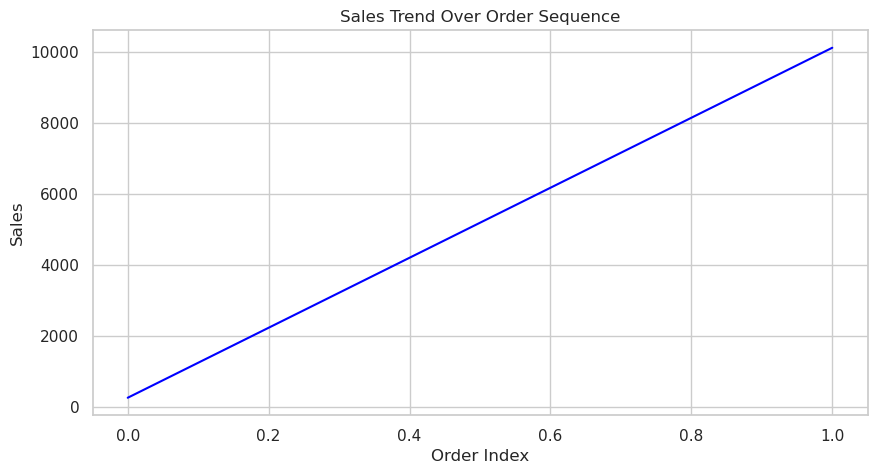

In [24]:
# Set seaborn style
sns.set(style="whitegrid")

# 1. Line chart (Sales trend over order sequence)
plt.figure(figsize=(10, 5))
plt.plot(df_clean.index, df_clean['Sales'], color='blue')
plt.title('Sales Trend Over Order Sequence')
plt.xlabel('Order Index')
plt.ylabel('Sales')
plt.show()

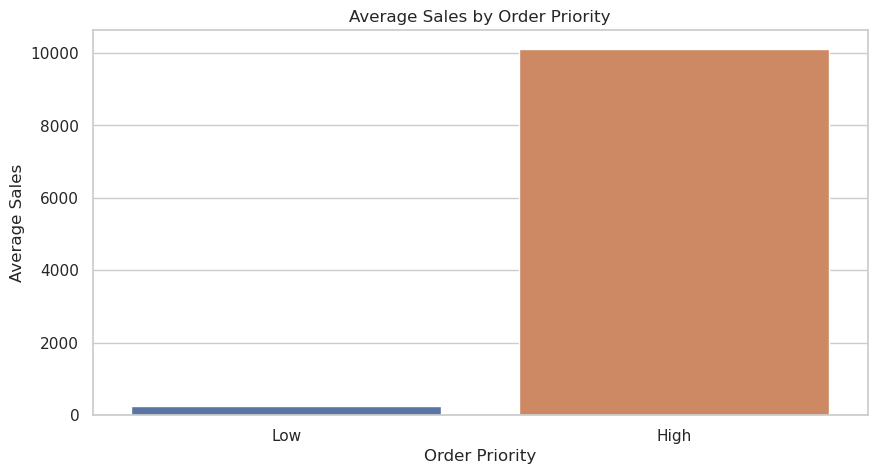

In [25]:
# 2. Bar chart (Average Sales by Order Priority)
plt.figure(figsize=(10, 5))
sns.barplot(x='Order Priority', y='Sales', data=df_clean, estimator='mean')
plt.title('Average Sales by Order Priority')
plt.xlabel('Order Priority')
plt.ylabel('Average Sales')
plt.show()

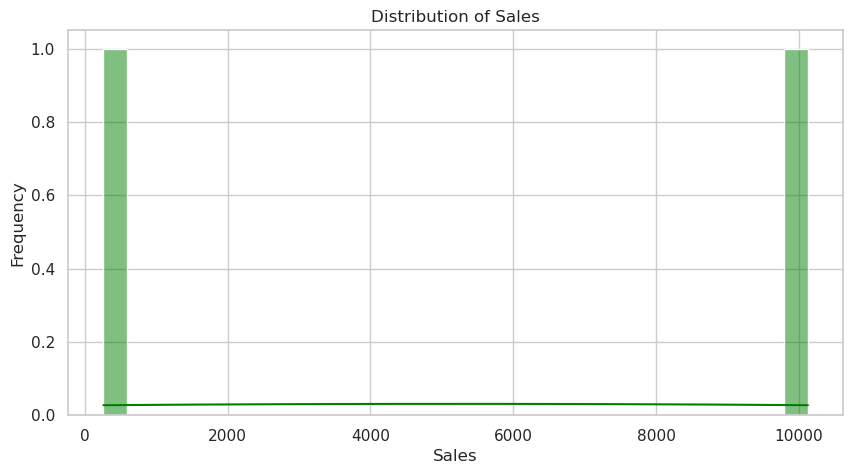

In [26]:
# 3. Histogram (Distribution of Sales)
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['Sales'], bins=30, kde=True, color='green')
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

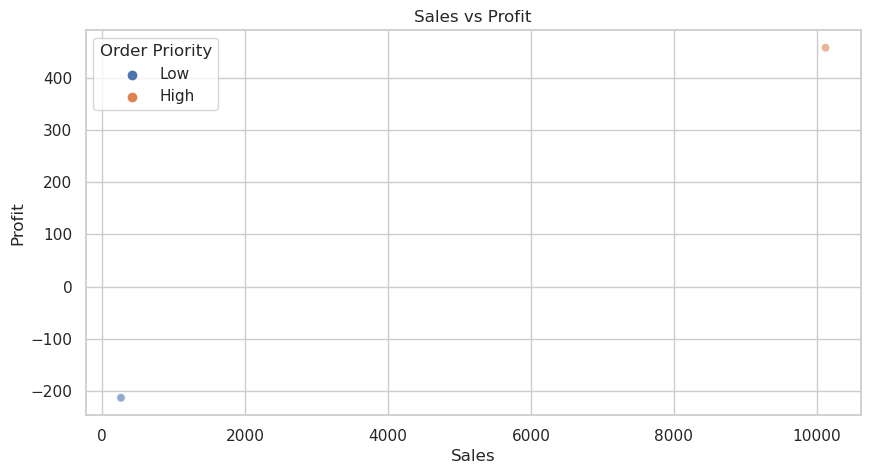

In [27]:
# 4. Scatter plot (Sales vs Profit)
plt.figure(figsize=(10, 5))
sns.scatterplot(x='Sales', y='Profit', data=df_clean, hue='Order Priority', alpha=0.6)
plt.title('Sales vs Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.legend(title='Order Priority')
plt.show()